# Beyond the Spread: Quantifying the Alignment Gap Between Battery Arbitrage and Energy System Resilience

**Research question.** Grid-scale batteries are dispatched to maximise trading profit.
How much of that profit-optimal behaviour coincides with what a resilient system needs —
discharging when the system is tight, absorbing when it is in surplus — and what does full
alignment cost?

**Data.** The most recent ~60 days of GB market and system data, all public and free:
Nord Pool N2EX day-ahead prices, Elexon MID / FUELHH generation / ITSDO demand,
Sheffield Solar PV_Live embedded solar, and per-BMU Physical Notifications for 23 real
grid-scale battery sites. No API keys; every number in this notebook is reproducible
from the repository's fetchers.

**Method.** (i) Settle a reference battery (50 MW / 2h) with the repository's
profit-optimising engine over the window. (ii) Classify every half-hour by system state:
*stress* = top decile of residual load (demand − wind − embedded solar) over the window;
*surplus* = bottom decile or negative prices. (iii) Score the alignment of the
profit-optimal dispatch and of each real site's Physical Notifications with the same
scorer. (iv) Solve a resilience-optimal counterfactual under identical physics and price
the gap between the two dispatches.

**Engine caveat, stated up front.** The benchmark settles with perfect-foresight intraday
against realised MID — an upper bound on price-responsiveness. Alignment measured on this
dispatch is therefore the *most* price-responsive case; a real trader tracks it from
below. Fleet revenue estimates are wholesale + BM only (ancillary income is not public),
and low-cycling ancillary-tilted sites are flagged and excluded from headline statistics.


In [1]:
%matplotlib inline

import datetime as dt
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from live import classify, fetch_live, resilience, settle
from live.assets import bess_config, build_assets
from fleet import fetch_fleet
from fleet import performance as fleet_perf
from src.bess.bess_asset import BESSAsset

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

# Consistent hexes with the dashboard's design system.
C = {
    "ink":       "#0b0b0b",
    "da":        "#2a78d6",
    "discharge": "#1baf7a",
    "charge":    "#eb6834",
    "cost":      "#e34948",
    "mid":       "#c98500",
    "ghost":     "#c3c2b7",
    "stress":    (0.89, 0.29, 0.28, 0.14),
    "surplus":   (0.11, 0.69, 0.48, 0.12),
}


# Reference asset: 50 MW / 2h (the modal new-build GB configuration), engine
# levers at production config values.
DURATION = "2h"
POWER_MW = 50.0
CFG = bess_config()
WINDOW_DAYS = 60

yesterday = dt.datetime.now(dt.timezone.utc).date() - dt.timedelta(days=1)
DATES = [yesterday - dt.timedelta(days=i) for i in range(WINDOW_DAYS - 1, -1, -1)]
print(f"Window requested : {DATES[0]} → {DATES[-1]}  ({WINDOW_DAYS} days)")
print(f"Asset            : {POWER_MW:.0f} MW × {DURATION} | cycle cap "
      f"{CFG.get('target_daily_cycles')} | slippage "
      f"£{CFG.get('execution', {}).get('slippage')}/MWh")

Window requested : 2026-05-20 → 2026-07-18  (60 days)
Asset            : 50 MW × 2h | cycle cap 1.5 | slippage £2.0/MWh


## 1. Settle the profit-optimal benchmark over the window

One asset, SOC carried day to day. Days whose price data is unavailable (Nord Pool serves
roughly the last 65 days) drop out of the window; every retained day settles with the
same engine the live dashboard runs.


In [2]:
assets = {DURATION: build_assets()[DURATION]}
prev = {DURATION: assets[DURATION].initial_soc_pct}
records = []
for date in DATES:
    try:
        prices = fetch_live.get_day_prices(date)
    except Exception:
        continue
    result = settle.settle_day(date, prices, CFG, assets, prev)
    if result is None:
        continue
    prev = {d: r.end_soc for d, r in result.durations.items()}
    try:
        context = fetch_live.get_day_context(date)
    except Exception:
        context = {}
    records.append({
        "date": date,
        "result": result.durations[DURATION],
        "labels": classify.classify(prices, context),
        "da_prices": prices["day_ahead_price"].tolist(),
    })

DATES_OK = [r["date"] for r in records]
net = pd.Series([r["result"].net_pnl for r in records], index=pd.to_datetime(DATES_OK))
print(f"Settled days     : {len(records)}  ({DATES_OK[0]} → {DATES_OK[-1]})")
print(f"Benchmark        : £{net.mean() / POWER_MW:,.0f}/MW/day mean · "
      f"£{net.sum():,.0f} total")

Settled days     : 60  (2026-05-20 → 2026-07-18)
Benchmark        : £96/MW/day mean · £289,135 total


## 2. Classify the system: stress and surplus

Residual load is what the rest of the fleet must serve after wind and embedded solar.
Thresholds are quantiles over the shown window, so "stress" means stressed relative to
this period — no external scarcity data enters. The hour-of-day distribution below is
context for every later figure: GB stress in this window is an evening phenomenon,
surplus a midday one.


Classified       : 2,880 half-hours over 60 days
Stress periods   : 288 (threshold 23.2 GW)
Surplus periods  : 290 (incl. 42 negative-price)


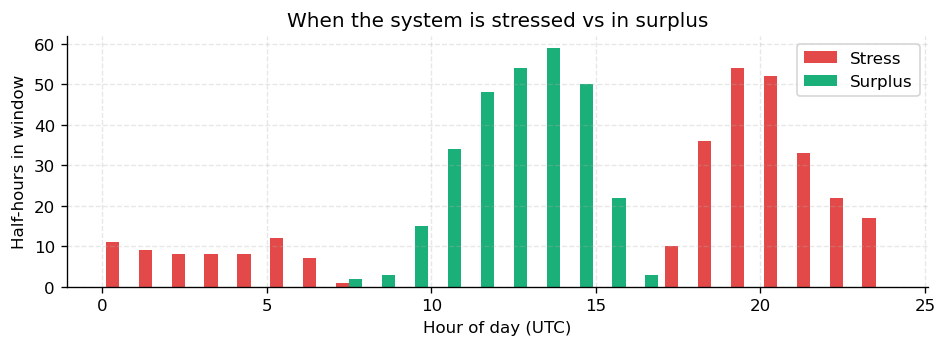

In [3]:
residual_parts, price_parts = [], []
for r in records:
    system = fetch_live.get_day_system(r["date"])
    if system.empty:
        continue
    residual_parts.append(resilience.residual_load(system))
    idx = pd.date_range(str(r["date"]), periods=len(r["da_prices"]), freq="1h", tz="UTC")
    price_parts.append(pd.Series(r["da_prices"], index=idx))

residual = pd.concat(residual_parts).sort_index()
da_series = pd.concat(price_parts).sort_index()
flags = resilience.classify_periods(residual, da_series)

hourly_flags = pd.DataFrame({
    "residual_mw": flags["residual_mw"].resample("1h").mean(),
    "stress": flags["stress"].resample("1h").max().astype(bool),
    "surplus": flags["surplus"].resample("1h").max().astype(bool),
}).dropna(subset=["residual_mw"])

print(f"Classified       : {len(flags):,} half-hours over {len(residual_parts)} days")
print(f"Stress periods   : {int(flags['stress'].sum())} "
      f"(threshold {flags['residual_mw'].quantile(resilience.STRESS_QUANTILE)/1000:,.1f} GW)")
print(f"Surplus periods  : {int(flags['surplus'].sum())} "
      f"(incl. {int((da_series.reindex(flags.index).ffill() < 0).sum())} negative-price)")

fig, ax = plt.subplots(figsize=(8, 3))
stress_hours = flags[flags["stress"]].index.hour
surplus_hours = flags[flags["surplus"]].index.hour
ax.hist([stress_hours, surplus_hours], bins=range(25),
        label=["Stress", "Surplus"], color=[C["cost"], C["discharge"]])
ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Half-hours in window")
ax.set_title("When the system is stressed vs in surplus")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Alignment of the profit-optimal dispatch

Three statistics, all computed from the settled dispatch and the classification above:
stress coverage (share of discharged energy delivered in stress periods), surplus
absorption (share of charged energy drawn in surplus periods), and readiness (mean state
of charge at the onset of each stress block). Figure 1 shows the mechanism on the
highest-stress day of the window.


In [4]:
dispatch_map, soc_map = {}, {}
for r in records:
    log = r["result"].dispatch_log
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    for ts, e in zip(idx, log):
        dispatch_map[ts] = e["final_mw"]
        soc_map[ts] = e["soc_before"]
sim_dispatch = pd.Series(dispatch_map).sort_index()
sim_soc = pd.Series(soc_map).sort_index()

scores = resilience.alignment_scores(sim_dispatch, hourly_flags)
readiness = resilience.readiness_at_stress(sim_soc, hourly_flags["stress"])
print(f"Stress coverage    : {scores['stress_coverage']:.1%}")
print(f"Surplus absorption : {scores['surplus_absorption']:.1%}")
print(f"Readiness at stress: {readiness:.1%}")
print(f"Dispatch–residual correlation: {scores['correlation']:+.2f}")

Stress coverage    : 40.4%
Surplus absorption : 38.7%
Readiness at stress: 69.1%
Dispatch–residual correlation: +0.41


/var/folders/wn/cym4_8ds6v12s3ph21msjsx00000gn/T/ipykernel_49931/3880419374.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


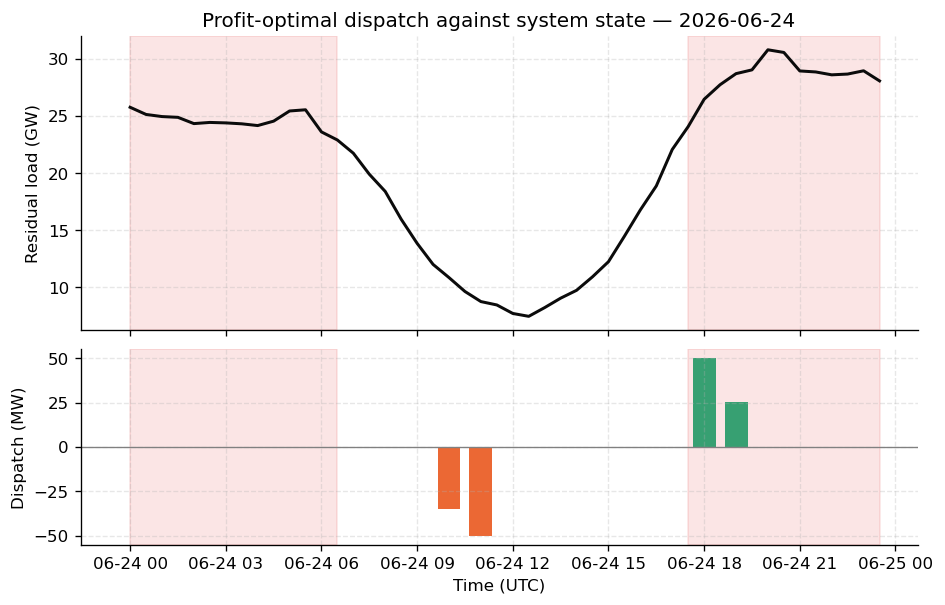

In [5]:
# Figure 1 — exemplar day: the day containing the window's highest residual load.
peak_ts = flags["residual_mw"].idxmax()
day = peak_ts.date()
day_flags = flags[flags.index.date == day]
day_disp = sim_dispatch[sim_dispatch.index.date == day]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
ax1.plot(day_flags.index, day_flags["residual_mw"] / 1000.0, color=C["ink"], lw=1.8)
ax1.set_ylabel("Residual load (GW)")
ax1.set_title(f"Profit-optimal dispatch against system state — {day}")
ax2.bar(day_disp.index, day_disp.values, width=0.03,
        color=[C["discharge"] if v > 0 else C["charge"] for v in day_disp.values])
ax2.axhline(0, color="grey", lw=0.8)
ax2.set_ylabel("Dispatch (MW)")
ax2.set_xlabel("Time (UTC)")
for ax in (ax1, ax2):
    for start, end, flag_col, colour in (
        (None, None, "stress", C["stress"]), (None, None, "surplus", C["surplus"]),
    ):
        in_span = False
        s = None
        series = day_flags[flag_col]
        for ts, val in series.items():
            if val and not in_span:
                s, in_span = ts, True
            elif not val and in_span:
                ax.axvspan(s, ts, color=colour)
                in_span = False
        if in_span:
            ax.axvspan(s, series.index[-1], color=colour)
plt.tight_layout()
plt.show()

## 4. The alignment gap

For every day, a resilience-optimal counterfactual is solved under identical physics
(same SOC window, power, efficiency and cycle cap; objective = deliver in stress, absorb
in surplus) starting from the same carried-over SOC. Both schedules are valued at cleared
DA prices with a symmetric terminal-inventory credit (day-end SOC change at the day-mean
price). Two numbers price the trade-off:

* **Cost of full alignment** — DA value the profit-optimal dispatch gives up by switching
  to the resilience-optimal schedule.
* **Stress delivery forgone** — stress-hour energy pure arbitrage leaves undelivered
  relative to the counterfactual.


Cost of full alignment : £52/MW/day (55% of DA value)
Stress MWh, arbitrage  : 2,055 MWh
Stress MWh, resilience : 2,549 MWh
Stress delivery forgone: 494 MWh (19% of the resilience-optimal delivery)


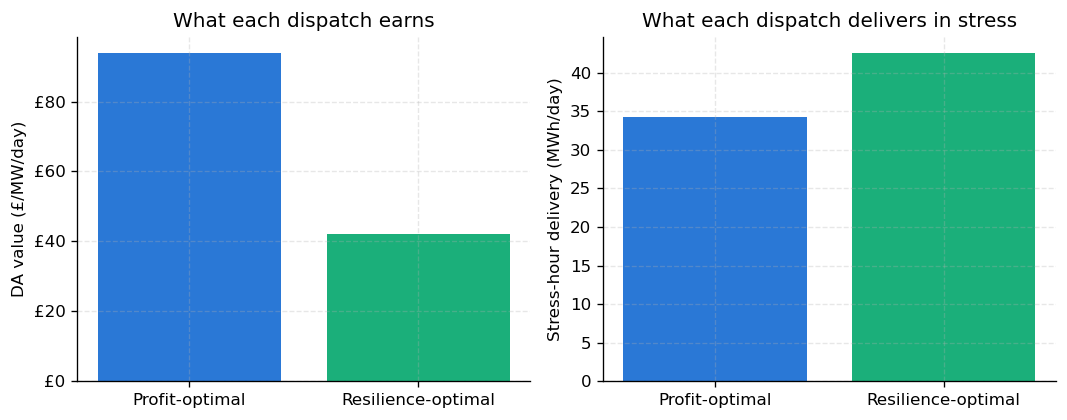

In [6]:
gap_rows = []
for r in records:
    log = r["result"].dispatch_log
    idx = pd.date_range(str(r["date"]), periods=len(log), freq="1h", tz="UTC")
    stress = hourly_flags["stress"].reindex(idx).fillna(False).tolist()
    surplus = hourly_flags["surplus"].reindex(idx).fillna(False).tolist()
    asset = BESSAsset(
        capacity_mwh=POWER_MW * 2, power_mw=POWER_MW,
        charge_efficiency=CFG["charge_efficiency"],
        discharge_efficiency=CFG["discharge_efficiency"],
        degradation_cost_per_mwh=CFG["degradation_cost_per_mwh"],
        initial_soc_pct=log[0]["soc_before"] if log else 0.5,
        min_soc_pct=CFG["min_soc_pct"], max_soc_pct=CFG["max_soc_pct"],
    )
    gap = resilience.alignment_gap(
        [e["final_mw"] for e in log], r["da_prices"], stress, surplus, asset,
        target_daily_cycles=CFG.get("target_daily_cycles"),
    )
    gap["date"] = r["date"]
    gap["labels"] = r["labels"]
    gap_rows.append(gap)
gap_df = pd.DataFrame(gap_rows)

mean_gap = gap_df["profit_cost_of_alignment"].mean() / POWER_MW
mean_profit = gap_df["profit_arb"].mean() / POWER_MW
print(f"Cost of full alignment : £{mean_gap:,.0f}/MW/day "
      f"({gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%} "
      f"of DA value)")
print(f"Stress MWh, arbitrage  : {gap_df['stress_mwh_arb'].sum():,.0f} MWh")
print(f"Stress MWh, resilience : {gap_df['stress_mwh_res'].sum():,.0f} MWh")
print(f"Stress delivery forgone: {gap_df['stress_mwh_forgone'].sum():,.0f} MWh "
      f"({gap_df['stress_mwh_forgone'].sum() / max(gap_df['stress_mwh_res'].sum(), 1e-9):.0%} "
      f"of the resilience-optimal delivery)")

# Figure 2 — the two dispatches on both value axes.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
labels = ["Profit-optimal", "Resilience-optimal"]
profit_vals = [gap_df["profit_arb"].mean() / POWER_MW, gap_df["profit_res"].mean() / POWER_MW]
stress_vals = [gap_df["stress_mwh_arb"].mean(), gap_df["stress_mwh_res"].mean()]
ax1.bar(labels, profit_vals, color=[C["da"], C["discharge"]])
ax1.set_ylabel("DA value (£/MW/day)")
ax1.set_title("What each dispatch earns")
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
ax2.bar(labels, stress_vals, color=[C["da"], C["discharge"]])
ax2.set_ylabel("Stress-hour delivery (MWh/day)")
ax2.set_title("What each dispatch delivers in stress")
plt.tight_layout()
plt.show()

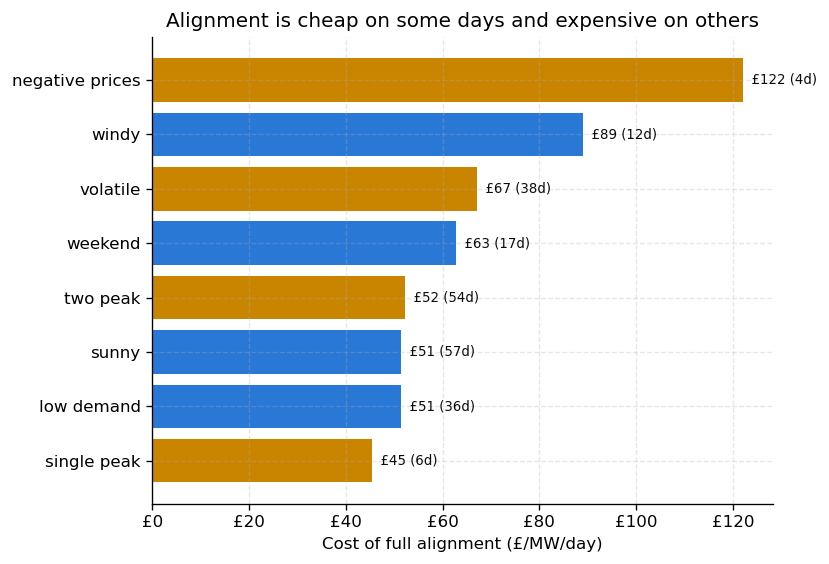

In [7]:
# Figure 3 — the gap is regime-dependent: cost of alignment by day type.
tag_rows = {}
for _, row in gap_df.iterrows():
    for tag in row["labels"] or []:
        slot = tag_rows.setdefault(tag, {"gap": 0.0, "days": 0,
                                          "driver": tag in classify.DRIVER_TAGS})
        slot["gap"] += row["profit_cost_of_alignment"] / POWER_MW
        slot["days"] += 1
by_tag = (pd.DataFrame([{"tag": k.replace("_", " "), **v} for k, v in tag_rows.items()])
          .assign(gap=lambda d: d["gap"] / d["days"])
          .sort_values("gap"))

fig, ax = plt.subplots(figsize=(7, 0.45 * len(by_tag) + 1.2))
ax.barh(by_tag["tag"], by_tag["gap"],
        color=[C["da"] if d else C["mid"] for d in by_tag["driver"]])
for y, (g, n) in enumerate(zip(by_tag["gap"], by_tag["days"])):
    ax.text(g, y, f"  £{g:,.0f} ({n}d)", va="center", fontsize=8, color=C["ink"])
ax.set_xlabel("Cost of full alignment (£/MW/day)")
ax.set_title("Alignment is cheap on some days and expensive on others")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. The real fleet on the profit/alignment plane

Each of the tracked GB battery sites is scored with the same classifier, from its actual
Physical Notifications, against the same window. Revenue is the public-data estimate
(PN × MID + BM cashflows); ancillary-tilted sites (cycling below 0.3 cycles/day) are
plotted but excluded from summary statistics, since their revenue is understated by
construction. The benchmark's position (star) shows where pure profit-optimal dispatch
lands on the same plane.


Sites scored          : 20  (17 in headline stats)
Fleet median coverage : 21.9%
Coverage–revenue corr : +0.13


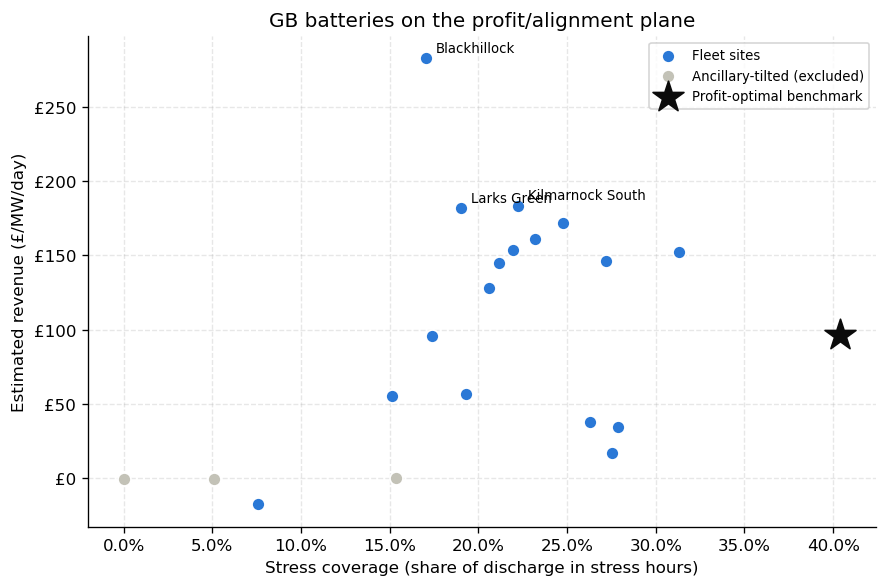

In [8]:
fleet_daily_rows = []
profile_parts = []
for date in DATES_OK:
    try:
        pn = fetch_fleet.fetch_fleet_pn(date)
        mid = fetch_fleet.fetch_day_mid_prices(date)
        cashflows = fetch_fleet.fetch_fleet_bm_cashflows(date)
    except Exception:
        continue
    day_metrics = fleet_perf.day_site_metrics(date.isoformat(), pn, cashflows, mid)
    if not day_metrics.empty:
        fleet_daily_rows.append(day_metrics)
    profile_parts.append(fleet_perf.site_profile(pn))

fleet_daily = pd.concat(fleet_daily_rows, ignore_index=True)
profiles = pd.concat(profile_parts, ignore_index=True)
site_df = fleet_perf.summarise_by_site(fleet_daily)

scatter_rows = []
for _, site in site_df.iterrows():
    mine = profiles[profiles["site"] == site["site"]]
    if mine.empty:
        continue
    s = resilience.alignment_scores(mine.set_index("time")["mw"].sort_index(), flags)
    if s["stress_coverage"] is None:
        continue
    scatter_rows.append({
        "site": site["site"],
        "coverage": s["stress_coverage"],
        "gbp": site["gbp_per_mw_day"],
        "excluded": bool(site["likely_ancillary"]),
    })
sc = pd.DataFrame(scatter_rows)
core = sc[~sc["excluded"]]
print(f"Sites scored          : {len(sc)}  ({len(core)} in headline stats)")
print(f"Fleet median coverage : {core['coverage'].median():.1%}")
print(f"Coverage–revenue corr : {core['coverage'].corr(core['gbp']):+.2f}")

sim_gbp = net.mean() / POWER_MW
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(core["coverage"], core["gbp"], s=60, color=C["da"],
           edgecolor="white", zorder=3, label="Fleet sites")
ghosts = sc[sc["excluded"]]
if not ghosts.empty:
    ax.scatter(ghosts["coverage"], ghosts["gbp"], s=60, color=C["ghost"],
               edgecolor="white", zorder=2, label="Ancillary-tilted (excluded)")
ax.scatter([scores["stress_coverage"]], [sim_gbp], marker="*", s=380,
           color=C["ink"], zorder=4, label="Profit-optimal benchmark")
for _, row in core.nlargest(3, "gbp").iterrows():
    ax.annotate(row["site"], (row["coverage"], row["gbp"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Stress coverage (share of discharge in stress hours)")
ax.set_ylabel("Estimated revenue (£/MW/day)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
ax.set_title("GB batteries on the profit/alignment plane")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Headline numbers and limitations

The cell below prints the poster's summary block. Limitations, for the paper's own
statement of scope:

1. **Stress is a residual-load proxy**, not NESO margin or loss-of-load data; demand is
   transmission-metered, so embedded generation nets off before it is observed.
2. **The benchmark's intraday layer has perfect foresight** of realised MID — alignment
   of this dispatch is the most price-responsive case, not a live-replicable strategy.
3. **Fleet revenue is wholesale + BM only**; ancillary income is invisible in public
   data, which is why low-cycling sites are excluded from headline statistics.
4. **One window, one asset configuration** (recent ~60 days, 50 MW / 2h). The gap is
   regime-dependent (Figure 3); a seasonal replication is the natural extension.
5. **The counterfactual monetises nothing for resilience** — it prices what full
   alignment costs, not what a market for it would pay. That framing is the point:
   the gap is the subsidy-free price of the behaviour the system would prefer.


In [9]:
print("=" * 64)
print("  ALIGNMENT GAP — HEADLINE NUMBERS")
print("=" * 64)
print(f"  Window                    : {DATES_OK[0]} → {DATES_OK[-1]} ({len(records)} days)")
print(f"  Reference asset           : {POWER_MW:.0f} MW × {DURATION}")
print(f"  Benchmark revenue         : £{sim_gbp:,.0f}/MW/day")
print(f"  Stress coverage           : {scores['stress_coverage']:.0%}")
print(f"  Surplus absorption        : {scores['surplus_absorption']:.0%}")
print(f"  Readiness at stress onset : {readiness:.0%}")
print(f"  Cost of full alignment    : £{mean_gap:,.0f}/MW/day "
      f"({gap_df['profit_cost_of_alignment'].sum() / gap_df['profit_arb'].sum():.0%} of DA value)")
print(f"  Stress delivery forgone   : "
      f"{gap_df['stress_mwh_forgone'].mean():,.0f} MWh/day")
print(f"  Fleet median coverage     : {core['coverage'].median():.0%} "
      f"(n={len(core)} sites)")
print(f"  Coverage–revenue corr     : {core['coverage'].corr(core['gbp']):+.2f}")
print("=" * 64)

  ALIGNMENT GAP — HEADLINE NUMBERS
  Window                    : 2026-05-20 → 2026-07-18 (60 days)
  Reference asset           : 50 MW × 2h
  Benchmark revenue         : £96/MW/day
  Stress coverage           : 40%
  Surplus absorption        : 39%
  Readiness at stress onset : 69%
  Cost of full alignment    : £52/MW/day (55% of DA value)
  Stress delivery forgone   : 8 MWh/day
  Fleet median coverage     : 22% (n=17 sites)
  Coverage–revenue corr     : +0.13
